# PropNavigator - Model Error Analysis



It loads the deployed model and asks: *where is the model accurate, where does it
struggle, and are its errors random or systematic?* 

Broken down by price bracket, property type and sector, with a look at the handful of rows that dominate the squared-error metrics.

The test split is imported from the pipeline module, so the rows are identical to
the ones the reported metrics come from.

## 1. Setup

In [5]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error, r2_score,
)

pd.set_option('display.max_rows', 120)
plt.rcParams['figure.figsize'] = (8, 4)

ROOT = Path.cwd()
while not (ROOT / 'artifacts').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.model_building.model_building import (
    create_train_val_test_split, inverse_transform_target, MODEL_PATH,
)

df = pd.read_csv(ROOT / 'data/fs/feature_selected_properties.csv')
X_train, X_val, X_test, y_train_log, y_val_log, y_test_log = create_train_val_test_split(df)
print('Test set:', X_test.shape)

Test set: (7607, 24)


## 2. Load the deployed model and predict

In [6]:
bundle = joblib.load(ROOT / MODEL_PATH)
pipeline = bundle['pipeline']
print('Deployed model:', bundle['model_name'],
      '| saved test MAPE:', bundle['test_mape_percent'], '%',
      '| trained:', bundle['trained_at'])

y_true = inverse_transform_target(y_test_log).values
y_pred = inverse_transform_target(pipeline.predict(X_test))

residuals = y_true - y_pred                    # + means under-predicted
signed_pct = residuals / y_true * 100          # - means over-predicted
abs_pct = np.abs(signed_pct)                   # The sign tells you the direction of the error
                                               # MAPE (Mean Absolute Percentage Error).how large the error was

test = X_test.copy()
test['y_true_cr'] = y_true
test['y_pred_cr'] = y_pred
test['residual_cr'] = residuals
test['signed_pct'] = signed_pct
test['abs_pct'] = abs_pct

Deployed model: LightGBM | saved test MAPE: 10.75 % | trained: 2026-09-10T11:18:04


## 3. Overall metrics

The mean and the median tell different stories. MAPE is the mean of absolute
percentage errors; the median shows what a *typical* property experiences.

In [7]:
summary = pd.DataFrame([
    ('MAPE (%)',           round(abs_pct.mean(), 2)),
    ('Median APE (%)',     round(float(np.median(abs_pct)), 2)),
    ('MAE (Cr)',           round(mean_absolute_error(y_true, y_pred), 3)),
    ('R2',                 round(r2_score(y_true, y_pred), 4)),
    ('P90 error (%)',      round(float(np.percentile(abs_pct, 90)), 1)),
    ('P95 error (%)',      round(float(np.percentile(abs_pct, 95)), 1)),
    ('Max error (%)',      round(float(abs_pct.max()), 0)),
    ('Mean bias (% of mean price)', round(residuals.mean() / y_true.mean() * 100, 2)),
    ('Test count',         int(len(y_true))),
], columns=['metric', 'value'])
summary

,metric,value
0,MAPE (%),10.7500
1,Median APE (%),6.4100
2,MAE (Cr),0.4480
3,R2,0.9333
4,P90 error (%),23.0000
5,P95 error (%),31.6000
6,Max error (%),533.0000
7,Mean bias (% of mean price),1.5800
8,Test count,7607.0000


MAPE = 10.75%. On average, a prediction is 10.75% away from the true price. This is the headline number, but "on average" hides a lot — see the next row.

Median APE = 6.41%. Half of all properties are predicted within 6.41%. This is what a typical user experiences. The gap between 6.41 and 10.75 tells you the error distribution has a long right tail: a minority of large misses is dragging the mean up. If someone asks "how accurate is it really?", the median is the more honest answer for the typical case.

MAE = ₹0.448 Cr. The average miss in rupees is about 45 lakh. Less interpretable than MAPE across a market this wide — 45 lakh is catastrophic on a 60-lakh flat and negligible on a 60-crore one — which is why MAPE is the primary metric. But it's the number a finance person will ask for.

R² = 0.9333. The model explains 93.3% of the variance in prices. 

R² = 0.9333 means the model explains about 93.3% of the variance in the target relative to a baseline that always predicts the mean.

Sounds excellent, and it is, but it's dominated by squared errors.

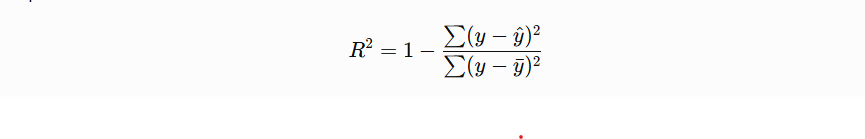

Because the numerator and denominator use squared rupee errors, large-price observations can have disproportionate influence.

so it mostly measures how well the model handles the expensive tail. We showed that dropping just twenty rows moves it to 0.963.

P90 = 23.0%. 90% of the test observations have an absolute percentage error ≤23%, while approximately 10% have an error greater than 23%.

For example:

Actual = ₹5 Cr
23% error = ₹1.15 Cr

So P90 tells you the distribution of individual prediction errors, not whether the model is appropriate for a particular financial decision.

Depends entirely on what the number is for. If a buyer is using your estimate to decide whether a listing is worth investigating — the product's actual purpose — then "nine in ten within a quarter" is useful. If they're using it to decide what to pay, a 23% miss on a ₹5 Cr flat is over a crore, and no. So: good for screening, not good for valuation. 

P95 = 31.6%. 95% of predictions have absolute percentage error ≤31.6%; approximately 5% exceed that error.

With 7,607 observations:

$$ 7,607 \times 5\% \approx 380 $$

So approximately 380 properties have an absolute percentage error greater than 31.6%.

5% = 1/20 

So:

About 1 out of every 20 test properties has an error greater than 31.6%. 

31.6% is approximately one-third:

In other words, One in twenty predictions is off by roughly a third or more.

For example, suppose a property is actually:

₹6 Cr

A 31.6% error corresponds to:

$$ 6 \times 0.316 = ₹1.896\text{ Cr} $$

So the prediction could be roughly:

₹4.10 Cr → 31.6% underprediction
₹7.90 Cr → 31.6% overprediction

because we're talking about absolute percentage error, so direction doesn't matter.

The important point is that P90/P95 describe the tail of the error distribution.

I use P90 and P95 to understand tail risk rather than relying only on average error. In this case, 90% of predictions are within 23%, while 95% are within 31.6%

Max = 533%. The single worst prediction was over five times the true price — a ₹20 lakh builder floor predicted at ₹1.27 Cr. Almost certainly a data problem or an extreme anomaly rather than the model working normally; for a screening tool it's arguably the correct flag.

Mean bias = +1.58%. 

Mean bias tells you whether the model is systematically predicting too high or too low overall.

How to Calculate :

Step 1: Calculate the residual for every property

For each property:

Residual = Actual Price − Predicted Price

Positive residual → under-prediction.
Negative residual → over-prediction.

Step 2: Take the mean residual

This tells you the model's average error in ₹ Cr.

Suppose:

Mean residual = +₹0.0619 Cr

That means, on average, the model's prediction is about ₹0.0619 Cr below the actual price.

Step 3: Divide by the mean actual price

+1.58% means the model's total predicted property value is 1.58% lower than the total actual property value.

Equivalently, the average residual is 1.58% of the average actual price.

Mean bias → systematic direction of aggregate error

MAPE tells you how far off predictions are. 
Your MAPE/P90/P95 tell you how accurate individual predictions are.
Mean bias tells you which way they lean.

Test count = 7,607. Enough that the MAPE has a standard error around 0.2 points and the bootstrap interval is [10.37%, 11.15%].

The one-sentence version: a typical prediction is within 6–7%, one in ten misses by more than 23%, the misses lean high for cheap properties and low for expensive ones, and a couple of dozen ultra-luxury listings account for most of the squared error.

Half of all predictions land within roughly 6.5% of the true price. The headline
MAPE is pulled upward by a long right tail - 5% of properties are off by more than
30%. Those two facts together are the honest description of the model.

The mean bias is small but positive: predictions run slightly low on average. That
is the retransformation effect of training in log space and is measured
separately in the model-building notebook.

I calculated residuals as actual minus predicted, then took the mean residual and normalized it by the mean actual price. The resulting mean bias was +1.58%. Since my residual is actual minus predicted, the positive value indicates that the model slightly under-predicts overall. In aggregate, the total predicted value is about 1.58% below the total actual value

Is +1.58% good?

It's relatively small at the aggregate level, so there isn't a large systematic over- or under-prediction overall. But I wouldn't judge the model using bias alone. I'd also look at MAPE, P90/P95 and bias by price segment, because aggregate bias can hide systematic behavior in particular groups

Why don't you just use MAPE

MAPE measures the magnitude of the errors but removes their direction by taking absolute values. Bias preserves the direction, so it tells me whether the model systematically leans high or low. I use both because they answer different questions.


## 4. Prediction interval coverage

The pipeline calibrates an error band on the **validation** set and stores it in
the artifact. Does that band actually hold on test?

If I create an 80% or 90% uncertainty band around my predictions, how many actual prices actually fall inside that band?

Why we need it

The model says a property is worth ₹2 crore.

That single number is a lie by omission. It sounds certain. The user has no idea whether the model means "₹2 Cr, give or take a few lakh" or "₹2 Cr, but honestly it could be anywhere from ₹1.5 to ₹2.5 Cr."

Those are completely different situations for someone deciding whether a ₹2.3 Cr asking price is reasonable. In the first case the listing looks overpriced. In the second it's well within the normal range.

We know from the error analysis that the model is typically off by around 6–10%, and sometimes much more. The user doesn't know that. Showing a bare number hides it.

So: we want to show a range instead of a point, and the range has to be based on how wrong the model actually tends to be.

How we calculate it

We need to know the model's typical error size. We measure it.

Step 1. Take the validation set — 7,607 properties the model didn't train on. For each one, we have the true price and the model's prediction.

Step 2. For each property, work out how far off the prediction was, as a percentage of the prediction:

property predicted at ₹2.0 Cr, actually sold at ₹2.3 Cr → the truth was 15% above the prediction
property predicted at ₹5.0 Cr, actually ₹4.5 Cr → the truth was 10% below the prediction

Do that 7,607 times. Now you have 7,607 percentages, some positive, some negative.

Why divide by the prediction and not the true price? Because when the app runs for a real user, we only have the prediction. We don't know the true price — that's what we're estimating. So the error has to be expressed relative to something we actually have.

Step 3. Sort those 7,607 percentages from most negative to most positive, and find where the middle 90% sits. Chop off the worst 5% at each end. For your model:

the 5th percentile is −21.0%
the 95th percentile is +23.3%

Meaning: on validation, 90% of the time the true price landed somewhere between 21% below and 23% above the prediction.

Step 4. Save those two numbers with the model. That's all residual_quantiles is — four saved numbers describing the model's typical error spread.

Step 5. In the app, apply them to any new prediction:

model predicts ₹2.00 Cr
low end: 2.00 × (1 − 0.210) = ₹1.58 Cr
high end: 2.00 × (1 + 0.233) = ₹2.47 Cr
shown to user: "estimated ₹2.0 Cr, typically ₹1.6–2.5 Cr"

What it conveys

To the user: how much to trust the number. A ₹2.3 Cr asking price sits inside ₹1.6–2.5 Cr, so it's unremarkable. A ₹3.2 Cr asking price sits outside it — worth investigating. That is literally the product: flagging listings priced unlike their comparables.

One thing to notice: the band isn't symmetric. It stretches 21% down but 23% up. Property prices have a long tail on the expensive side, so the model gets surprised upward more often than downward.

And the check we ran

Here's the part that was probably confusing you, because it's a separate step from everything above.

The band was measured on the validation set. But there's no guarantee a band measured on one set of properties describes a different set of properties. Maybe validation happened to be easy and the band is too narrow.

So we tested it. Take the 7,607 test properties — never used for anything — and count how many fall inside the band.

if the band is honest, about 90% should fall inside
89.4% actually did

And for the narrower 80% band, 79.5% fell inside against a target of 80%.

So the range the app shows is truthful. When it implies "90% confident," it really is right about 90% of the time on data it has never seen. That's the whole point of the check — a range that overpromises would be worse than no range at all.

The honest limitation

It's one band for every property. A standard 3BHK in a dense sector with hundreds of comparables gets the same ±21/23% as an unusual independent house the model barely understands.

But we know from the error analysis those aren't equally predictable — error runs 9.2% in the ₹3–5 Cr bracket and 18.6% below ₹1 Cr. So the single band is too wide for easy properties and too narrow for hard ones.

Fixing that means per-property intervals rather than one global one. That's what quantile regression or conformal prediction would give you, and it's the natural next improvement.

In [8]:
q = bundle['residual_quantiles']
rel = (y_true - y_pred) / y_pred          # same definition the pipeline uses

coverage = pd.DataFrame([
    ('90% band', f"[{q['q05']:+.3f}, {q['q95']:+.3f}]",
     round(((rel >= q['q05']) & (rel <= q['q95'])).mean() * 100, 1), 90),
    ('80% band', f"[{q['q10']:+.3f}, {q['q90']:+.3f}]",
     round(((rel >= q['q10']) & (rel <= q['q90'])).mean() * 100, 1), 80),
], columns=['band', 'limits', 'test coverage %', 'target %'])
coverage

,band,limits,test coverage %,target %
0,90% band,"[-0.210, +0.233]",89.4,90
1,80% band,"[-0.146, +0.152]",79.5,80


The validation-calibrated band transfers to test almost exactly. That is the
result you want: the interval the app shows a user is honest.

The limitation is that it is one global band. The next section shows that the
error is far from uniform across price brackets, so a per-band interval would be
tighter for typical properties and wider for the extremes.

## 5. Errors by price bracket - are they random or systematic?

Two things per bracket: how large the errors are (MAPE) and which **direction**
they lean (mean signed error). A model whose errors are random should show bias
near zero everywhere.

In [12]:
brackets = pd.cut(
    pd.Series(y_true), bins=[0, 1, 3, 5, 10, np.inf],
    labels=['<1 Cr', '1-3 Cr', '3-5 Cr', '5-10 Cr', '10+ Cr'],
)

by_bracket = test.groupby(brackets.values, observed=True).agg(
    count=('y_true_cr', 'size'),
    mape=('abs_pct', 'mean'),
    bias_pct=('signed_pct', 'mean'),
    mae_cr=('residual_cr', lambda r: np.abs(r).mean()),
).round({'mape': 1, 'bias_pct': 1, 'mae_cr': 3})
by_bracket

,count,mape,bias_pct,mae_cr
<1 Cr,683,18.6,-12.7,0.116
1-3 Cr,3498,9.5,-3.5,0.195
3-5 Cr,1985,9.2,-0.3,0.356
5-10 Cr,1050,11.5,1.8,0.774
10+ Cr,391,14.2,6.9,2.879


**The errors are directional.** Negative bias means the model predicts *too high*;
positive means *too low*. Reading down the table: the model over-predicts cheap
properties, is close to unbiased in the 3-5 Cr middle, and under-predicts expensive
ones. That is shrinkage toward the centre of the distribution - a well-known
property of any model fitted by minimising a loss: extreme values are pulled toward
the mean because the model has fewer examples there and regularisation resists
extreme predictions.

It is also the single most actionable finding in this notebook. A bias that
depends on price bracket can be corrected after the fact with a per-bracket
calibration - and the direction tells a user something useful: an estimate above
10 Cr is probably conservative, an estimate below 1 Cr is probably generous.

## 6. Errors by property type

In [9]:
by_type = test.groupby('property_type').agg(
    count=('y_true_cr', 'size'),
    mape=('abs_pct', 'mean'),
    median_ape=('abs_pct', 'median'),
    bias_pct=('signed_pct', 'mean'),
).round(1).sort_values('mape', ascending=False)
by_type

,count,mape,median_ape,bias_pct
property_type,,,,
Independent House,323,28.9,15.4,-11.8
Independent Builder Floor,1761,11.4,8.0,-1.3
Flat,5523,9.5,5.8,-2.0


Independent houses are the weak segment by a wide margin, and the model
over-predicts them substantially. Two reasons, both structural: houses are a small
share of the data, so the model has less to learn from; and the features that
drive house prices - plot size, construction quality, age of the structure - are
either absent or only weakly captured by the columns we have. A super built-up
area figure describes a flat well and a house on a plot poorly.

## 7. Errors by sector - worst and best

In [10]:
def segment_metrics(labels, min_count=5):
    g = test.groupby(labels, observed=True)
    out = g.agg(
        count=('y_true_cr', 'size'),
        mape=('abs_pct', 'mean'),
        bias_pct=('signed_pct', 'mean'),
        median_price_cr=('y_true_cr', 'median'),
    )
    return out[out['count'] >= min_count].round({'mape': 1, 'bias_pct': 1, 'median_price_cr': 2})


by_sector = segment_metrics(test['sector'].values)

print('Worst 10 sectors by MAPE:')
display(by_sector.sort_values('mape', ascending=False).head(10))
print('\nBest 10 sectors by MAPE:')
display(by_sector.sort_values('mape').head(10))

Worst 10 sectors by MAPE:


,count,mape,bias_pct,median_price_cr
other,52,39.2,-24.6,2.45
dlf cyber city,7,37.6,-31.2,4.50
sector 55,7,28.7,-26.3,2.40
sector 7,6,27.6,-27.6,2.80
suncity,19,24.9,-14.4,5.50
sector 10,5,23.7,4.6,6.50
sector 30,9,22.9,-13.2,5.10
sector 51,40,22.7,-11.2,2.94
dlf phase 3,39,20.3,-4.2,6.25
sector 33,26,20.0,-14.9,2.55



Best 10 sectors by MAPE:


,count,mape,bias_pct,median_price_cr
sector 4,5,3.2,2.4,4.90
sector 74,9,3.8,-2.1,3.15
heritage city,7,3.9,1.1,5.40
sector 88,75,4.6,0.7,2.20
sector 40,6,5.2,0.4,3.38
sector 91,31,5.8,-0.9,2.10
sector 77,94,6.3,-1.3,2.62
sector 59,77,6.5,-0.7,5.60
sector 86,104,6.6,-0.1,2.15
sector 90,83,6.8,-1.5,2.05


## 8. The rows that dominate the squared-error metrics

R2 and RMSE are built from squared errors, so a few very large rupee misses can
outweigh thousands of ordinary ones. How concentrated is the error?

In [13]:
order = np.argsort(-np.abs(residuals))
top20 = order[:20]
rest = np.ones(len(y_true), dtype=bool)
rest[top20] = False

sq = residuals ** 2
print(f'Rows                         : {len(y_true)}')
print(f'Top 20 as share of rows      : {20 / len(y_true) * 100:.2f}%')
print(f'Top 20 as share of squared error : {sq[top20].sum() / sq.sum() * 100:.1f}%')
print()
print(f'R2 with all rows             : {r2_score(y_true, y_pred):.4f}')
print(f'R2 without the top 20        : {r2_score(y_true[rest], y_pred[rest]):.4f}')
print()
print(f'MAPE with all rows           : {abs_pct.mean():.2f}%')
print(f'MAPE without the top 20      : {abs_pct[rest].mean():.2f}%')

Rows                         : 7607
Top 20 as share of rows      : 0.26%
Top 20 as share of squared error : 60.8%

R2 with all rows             : 0.9333
R2 without the top 20        : 0.9630

MAPE with all rows           : 10.75%
MAPE without the top 20      : 10.65%


A quarter of one percent of the rows carries the majority of the squared error.
Removing them barely moves MAPE but lifts R2 substantially.

This is why the model ranking earlier flipped between MAPE and R2: the two metrics
are effectively measuring different subsets of the data. MAPE describes the typical
property; R2 describes the twenty worst.

In [14]:
cols = ['property_type', 'sector', 'area', 'bedRoom', 'y_true_cr', 'y_pred_cr', 'residual_cr', 'signed_pct']
worst_rupee = test.iloc[top20][cols].round(2)
worst_rupee

,property_type,sector,area,bedRoom,y_true_cr,y_pred_cr,residual_cr,signed_pct
29671,Flat,sector 42,14903.0,5,85.0,46.88,38.12,44.85
100,Flat,ambience island,15500.0,8,65.0,29.35,35.65,54.84
16014,Independent Builder Floor,dlf phase 1,4518.0,3,38.0,5.45,32.55,85.66
8906,Flat,ambience island,16000.0,7,62.0,31.87,30.13,48.60
13874,Flat,sector 42,11500.0,5,95.0,73.44,21.56,22.69
19678,Flat,sector 42,10777.0,5,80.0,58.68,21.32,26.65
25950,Flat,sector 42,10777.0,5,83.0,63.81,19.19,23.13
2200,Flat,sector 42,9000.0,5,90.0,107.10,-17.10,-19.00
6990,Flat,sector 62,10019.0,5,35.0,19.00,16.00,45.72
17725,Independent House,sector 46,13041.0,6,5.3,21.14,-15.84,-298.86


**What the worst rupee errors have in common.** They are almost all ultra-luxury
flats - very large units in sector 42 (Golf Course Road) and Ambience Island,
priced at 60-95 Cr, which the model under-predicts by 20-40 Cr. At that end of
the market there are a few dozen comparable listings in the whole dataset, and
the price depends on things no column captures: which tower, which floor, the
specific developer, the finish.

At least one row is a probable data error rather than a model failure - a builder
floor of ordinary size listed at a price that would put it in the most expensive
building in the city. The model's *disagreement* with the listing is arguably the
right output for a screening tool.

## 9. The worst percentage errors - a different population

Sorting by percentage error instead of rupees surfaces a completely different set
of rows.

In [ ]:
worst_pct = test.sort_values('abs_pct', ascending=False).head(20)[cols].round(2)
worst_pct

These are all **cheap properties predicted far too high** - listings at 20 to 70
lakh that the model prices at 1.3 to 2.4 Cr. Several sit in the `other` sector
bucket, where the location signal has been deliberately coarsened, and at least
one looks like a plot or land listing miscategorised as a house.

Two populations, two failure modes: the rupee tail is the model struggling with
genuine ultra-luxury scarcity; the percentage tail is mostly the model applying
sector-typical pricing to listings that are either mislabelled or genuinely
anomalous. For a screening product, both are listings a buyer should look at
twice - which is exactly the intended use.

## 10. Visual diagnostics

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# Predicted vs actual, clipped at the 99th percentile so the luxury tail does
# not squash everything else into the corner.
lim = [0, float(np.percentile(y_true, 99))]
ax[0].scatter(y_true, y_pred, s=6, alpha=0.3)
ax[0].plot(lim, lim, 'r--', label='perfect')
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel('Actual (Cr)'); ax[0].set_ylabel('Predicted (Cr)')
ax[0].set_title('Predicted vs actual (to 99th pct)')
ax[0].legend()

# Signed bias by bracket - the shrinkage picture.
ax[1].bar(by_bracket.index.astype(str), by_bracket['bias_pct'],
          color=['tab:red' if v < 0 else 'tab:blue' for v in by_bracket['bias_pct']])
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_ylabel('mean signed error %  (+ = under-predict)')
ax[1].set_title('Bias by price bracket')
ax[1].tick_params(axis='x', rotation=30)

# Error distribution, tail clipped for readability.
ax[2].hist(abs_pct[abs_pct < 100], bins=60)
ax[2].axvline(np.median(abs_pct), color='tab:orange', ls='--', label=f'median {np.median(abs_pct):.1f}%')
ax[2].axvline(abs_pct.mean(), color='tab:red', ls='--', label=f'mean {abs_pct.mean():.1f}%')
ax[2].set_xlabel('absolute % error'); ax[2].set_title('Error distribution (<100%)')
ax[2].legend()

plt.tight_layout()
plt.show()

## 11. Save the breakdown

In [ ]:
out = ROOT / 'data/error_analysis'
out.mkdir(parents=True, exist_ok=True)

summary.to_csv(out / 'error_summary.csv', index=False)
coverage.to_csv(out / 'interval_coverage.csv', index=False)
pd.concat([
    by_bracket.reset_index().rename(columns={'index': 'segment'}).assign(segment_type='price_bracket'),
    by_type.reset_index().rename(columns={'property_type': 'segment'}).assign(segment_type='property_type'),
    by_sector.reset_index().rename(columns={'sector': 'segment'}).assign(segment_type='sector'),
], ignore_index=True).to_csv(out / 'segment_metrics.csv', index=False)
worst_rupee.to_csv(out / 'worst_predictions_by_rupee.csv', index=False)
worst_pct.to_csv(out / 'worst_predictions_by_pct.csv', index=False)
print('Saved to', out)

## 12. Findings

**1. A typical prediction is within 6.5%; the headline 10.75% is pulled up by a
tail.** Median absolute error is well below the mean, and 5% of properties are off
by more than 30%. Both numbers belong in any honest description of the model.

**2. The errors are systematic, not random.** The model over-predicts below 1 Cr
by about 13% and under-predicts above 10 Cr by about 7%, with the 3-5 Cr middle
nearly unbiased. That is shrinkage toward the centre, and it is correctable with a
per-bracket calibration. It also gives users a directional hint: high estimates
are probably conservative, low ones probably generous.

**3. Independent houses are the weak segment** - roughly three times the error of
flats, and over-predicted by about 12%. The features available describe flats
well and houses on plots poorly.

**4. Twenty rows carry the majority of the squared error.** They are ultra-luxury
flats on Golf Course Road and Ambience Island, under-predicted by 20-40 Cr, plus
one or two probable data errors. Removing them lifts R2 from 0.93 to 0.96 while
MAPE barely moves - which is exactly why MAPE and R2 disagreed about which model
was best.

**5. The worst percentage errors are a different population**: cheap listings
predicted far too high, many in the coarsened `other` sector bucket, some probably
mislabelled. For a screening tool that flags listings priced unlike their
comparables, these are correct outputs.

**6. The prediction interval is honest.** The validation-calibrated 90% band covers
89.4% of test rows. It is a single global band, though, and finding 2 says a
per-bracket band would serve users better.

### What this argues for next

Per-bracket bias correction is cheap and directly addresses finding 2. Quantile
regression or conformal prediction would give per-property intervals that widen
at the extremes where the model is least certain. And the independent-house
segment would benefit most from a feature the data does not currently have: plot
area separate from built-up area.